<a href="https://colab.research.google.com/github/VitorBZS/Avaliacao-02-AAPL-Apple-Volatilidade/blob/main/Hoje_1706prova_02_vitor_bonilha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02: AAPL (APPLE) | Volatilidade:
Alvo ($Y$): Alta_Volatilidade se (high - low) superar a média histórica de 100 dias.

Desafio: Normalizar rigorosamente a amplitude e gerar seu histograma.

## Aluno: Vitor Hugo Bonilha Zanatta Silva

#1. Extração

##Configurações

In [ ]:
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

##Extração e Conversão Inicial

In [ ]:
df = yf.download("AAPL", period="5y")
df.columns = ["open", "high", "low", "close", "volume"]
df = df.astype(float)
df.index = pd.to_datetime(df.index)
df.sort_index(ascending = True, inplace = True)

df.head()

/tmp/ipykernel_12286/2954661374.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", period="5y")
[*********************100%***********************]  1 of 1 completed


,open,high,low,close,volume
Date,,,,,
2021-06-18,127.166122,128.189600,126.951676,127.409810,108953300.0
2021-06-21,128.959702,129.066925,125.947721,127.010197,79663300.0
2021-06-22,130.597260,130.694741,128.296844,128.793977,74783600.0
2021-06-23,130.324326,130.928682,129.866191,130.392565,60214200.0
2021-06-24,130.041656,131.240597,129.573765,131.055392,68711000.0


#2. Tratamento e Normalização

## Verificação de Nulos

In [ ]:
print(df.isnull().sum())

open      0
high      0
low       0
close     0
volume    0
dtype: int64


## Engenharia de Preditores (X)

In [ ]:
df['amplitude'] = df['high'] - df['low']
df['X_amplitude'] = df['amplitude'].shift(1)
df['X_volume'] = df['volume'].shift(1)
df['X_retorno'] = df['close'].pct_change().abs().shift(1)
df_clean = df.dropna().copy()

## Aplicação do StandardScaler

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[['X_amplitude', 'X_volume', 'X_retorno']])

## DataFrame de Preditores (X)

In [ ]:
X = pd.DataFrame(X_scaled, columns = ['amplitude_norm', 'volume_norm', 'ret_norm'], index = df_clean.index)

#3. Visualização

## DESAFIO: Histograma da Amplitude Normalizada

Text(0.5, 1.0, 'Histograma: Amplitude Normalizada')

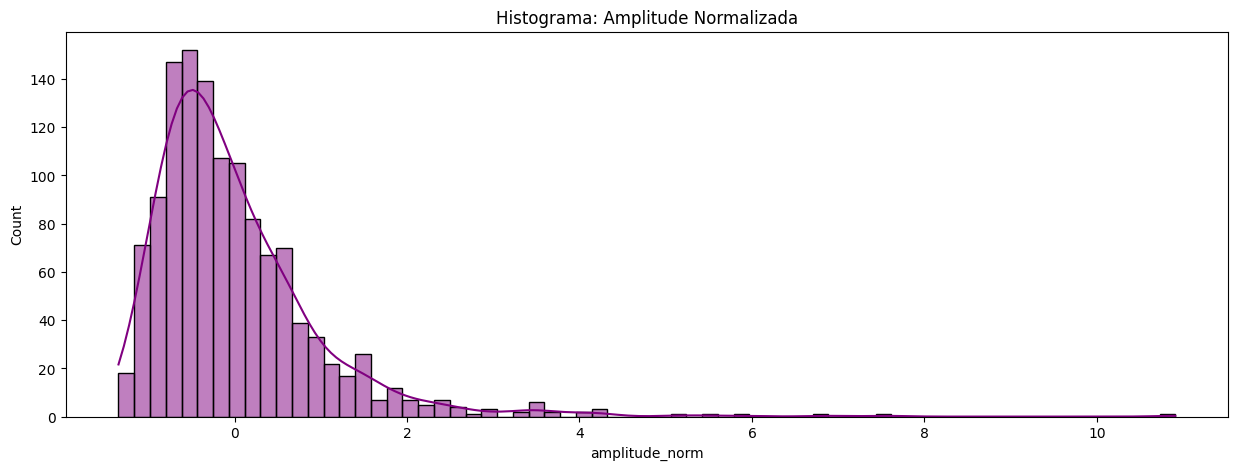

In [ ]:
plt.figure(figsize = (15, 5))


sns.histplot(X['amplitude_norm'], kde = True, color = 'purple')
plt.title('Histograma: Amplitude Normalizada')

#4. Laborização (Feature Engineering)

## Média Móvel

In [ ]:
df_clean['media_100'] = df_clean['amplitude'].shift(1).rolling(window = 200, min_periods = 200).mean()

In [ ]:
df_clean['Y'] = (df_clean['amplitude'] > df_clean['media_100']).astype(int)

In [ ]:
df_final = df_clean.dropna().copy()

In [ ]:
print("Distribuição das classes (0: Baixa, 1: Alta):")
print(df_final['Y'].value_counts())

Distribuição das classes (0: Baixa, 1: Alta):
Y
0    606
1    447
Name: count, dtype: int64


#5. Ingestão Bayesiana

## Sincronizando os finais

In [ ]:
y_final = df_final['Y']
X_final = X.loc[df_final.index]

## Divisão temporal

In [ ]:
split_index = int(len(X_final) * 0.8)

X_train = X_final.iloc[:split_index]
X_test = X_final.iloc[split_index:]
y_train = y_final.iloc[:split_index]
y_test = y_final.iloc[split_index:]

## Treinamento do Modelo GaussianNB Naive Bayes

In [ ]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

## Predição

In [ ]:
y_pred = model.predict(X_test)

print(f"Acurácia Final: {accuracy_score(y_test, y_pred):.2%}")
print("\nRelatório de Classificação: \n", classification_report(y_test, y_pred))

Acurácia Final: 58.29%

Relatório de Classificação: 
               precision    recall  f1-score   support

           0       0.58      0.81      0.68       114
           1       0.58      0.32      0.41        97

    accuracy                           0.58       211
   macro avg       0.58      0.56      0.54       211
weighted avg       0.58      0.58      0.56       211



## Matrix de Confusão

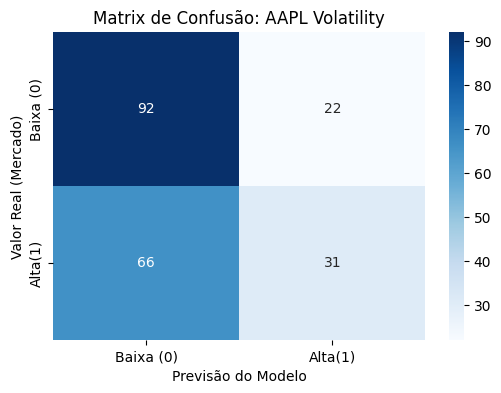

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot = True, fmt='d', cmap='Blues',
            xticklabels = ['Baixa (0)', 'Alta(1)'],
            yticklabels = ['Baixa (0)', 'Alta(1)'])

plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real (Mercado)')
plt.title('Matrix de Confusão: AAPL Volatility')
plt.show()

## TreeMap

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion='entropy', random_state=0)
dt_model.fit(X_train, y_train)


dt_pred = dt_model.predict(X_test)
print("--- Árvore de Decisão ---")
print(classification_report(y_test, dt_pred))

--- Árvore de Decisão ---
              precision    recall  f1-score   support

           0       0.54      0.46      0.50       114
           1       0.46      0.54      0.50        97

    accuracy                           0.50       211
   macro avg       0.50      0.50      0.50       211
weighted avg       0.50      0.50      0.50       211



## Random Forest (Ensemble)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instanciar
rf_model = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
rf_model.fit(X_train, y_train)

# Predição e Avaliação
rf_pred = rf_model.predict(X_test)
print("--- Random Forest ---")
print(classification_report(y_test, rf_pred))

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.55      0.61      0.58       114
           1       0.48      0.41      0.44        97

    accuracy                           0.52       211
   macro avg       0.51      0.51      0.51       211
weighted avg       0.52      0.52      0.52       211



##  Support Vector Machines (SVM)

In [ ]:
from sklearn.svm import SVC

# Instanciar (O kernel 'rbf' é o padrão para relações não-lineares)
svm_model = SVC(kernel='rbf', random_state=1, C=2.0)
svm_model.fit(X_train, y_train)

# Predição e Avaliação
svm_pred = svm_model.predict(X_test)
print("--- SVM (Support Vector Machine) ---")
print(classification_report(y_test, svm_pred))

--- SVM (Support Vector Machine) ---
              precision    recall  f1-score   support

           0       0.60      0.74      0.66       114
           1       0.58      0.43      0.50        97

    accuracy                           0.60       211
   macro avg       0.59      0.58      0.58       211
weighted avg       0.59      0.60      0.59       211



## K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
print("--- KNN (K-Neighbors) ---")
print(classification_report(y_test, knn_pred))

--- KNN (K-Neighbors) ---
              precision    recall  f1-score   support

           0       0.55      0.54      0.54       114
           1       0.48      0.49      0.48        97

    accuracy                           0.52       211
   macro avg       0.51      0.51      0.51       211
weighted avg       0.52      0.52      0.52       211



##  Rede Neural (MLP Classifier)

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(verbose = True, max_iter=1000,
                                  tol=0.000010, solver='adam',
                                  hidden_layer_sizes=(100), activation='relu')
mlp_model.fit(X_train, y_train)

mlp_pred = mlp_model.predict(X_test)
print("--- Rede Neural (MLP) ---")
print(classification_report(y_test, mlp_pred))

Iteration 1, loss = 0.71024366
Iteration 2, loss = 0.69410698
Iteration 3, loss = 0.68199772
Iteration 4, loss = 0.67332321
Iteration 5, loss = 0.66670297
Iteration 6, loss = 0.66111633
Iteration 7, loss = 0.65752890
Iteration 8, loss = 0.65454339
Iteration 9, loss = 0.65245258
Iteration 10, loss = 0.65076843
Iteration 11, loss = 0.65004659
Iteration 12, loss = 0.64922800
Iteration 13, loss = 0.64825915
Iteration 14, loss = 0.64765759
Iteration 15, loss = 0.64703632
Iteration 16, loss = 0.64640892
Iteration 17, loss = 0.64596425
Iteration 18, loss = 0.64554072
Iteration 19, loss = 0.64500352
Iteration 20, loss = 0.64451161
Iteration 21, loss = 0.64396844
Iteration 22, loss = 0.64370055
Iteration 23, loss = 0.64339381
Iteration 24, loss = 0.64314962
Iteration 25, loss = 0.64297579
Iteration 26, loss = 0.64256647
Iteration 27, loss = 0.64230070
Iteration 28, loss = 0.64212862
Iteration 29, loss = 0.64181645
Iteration 30, loss = 0.64157311
Iteration 31, loss = 0.64145202
Iteration 32, los